# PART B – **ANN FOR CLASSIFICATION**

# Import libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
print("Name : Adhiraj S C")
print("Roll No : 24BAD003")

Name : Adhiraj S C
Roll No : 24BAD003


# Load dataset

In [48]:
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
data = load_breast_cancer()

# Features (Input)
X = data.data

# Target (Output)
y = data.target
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


# Split data into train and test sets

In [49]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling the feature

In [50]:
# Create the StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test = scaler.transform(X_test)

# Build ANN model

In [51]:

model = Sequential([
    Dense(16, activation='relu', input_shape=(30,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile the model

In [52]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model

In [53]:

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5385 - loss: 0.6913 - val_accuracy: 0.6813 - val_loss: 0.6032
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6923 - loss: 0.5748 - val_accuracy: 0.7802 - val_loss: 0.5074
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7720 - loss: 0.4853 - val_accuracy: 0.8132 - val_loss: 0.4360
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8462 - loss: 0.4145 - val_accuracy: 0.8571 - val_loss: 0.3825
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8984 - loss: 0.3577 - val_accuracy: 0.9011 - val_loss: 0.3371
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9203 - loss: 0.3089 - val_accuracy: 0.9121 - val_loss: 0.2962
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9368 - loss: 0.2650 - val_accuracy: 0.9231 - val_loss: 0.2615
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9423 - loss: 0.2270 - val_accuracy: 0.9341 - v

# Prediction

In [54]:
# Predict probabilities for the test data
y_pred = model.predict(X_test)

# Convert probabilities into class labels (0 or 1)
y_pred = (y_pred > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


# Evaluation Metrics

Accuracy : 0.97
Precision: 0.97
Recall   : 0.99
F1-Score : 0.98


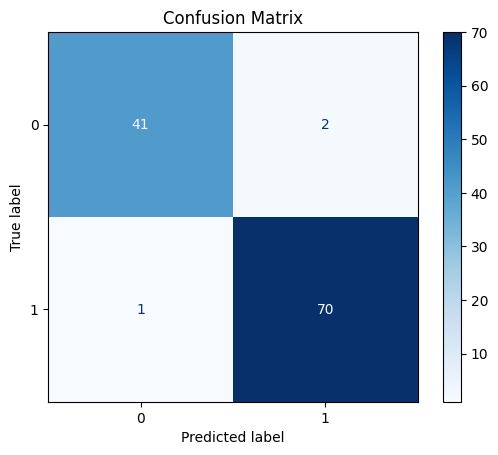

In [55]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print("Accuracy :", round(accuracy,2))
print("Precision:", round(precision,2))
print("Recall   :", round(recall,2))
print("F1-Score :", round(f1,2))

# Display the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Visualizations

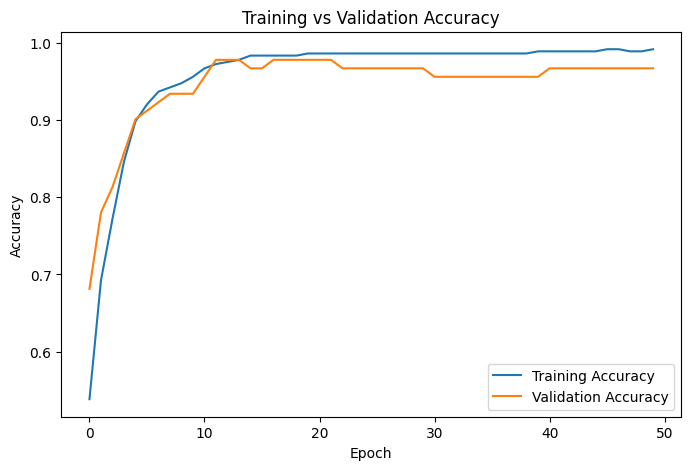

In [56]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()